In [3]:
# Starting with Data cleaning and preprocessing

# Importing the libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#data exploration
# Importing the dataset
dataset = pd.read_csv('crime_data.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 3].values
#show the data
print(dataset.head())


  Disposition OffenderStatus Offender_Race Offender_Gender  Offender_Age  \
0      CLOSED       ARRESTED         BLACK            MALE          30.0   
1      CLOSED       ARRESTED         BLACK            MALE          30.0   
2      CLOSED       ARRESTED         BLACK            MALE          30.0   
3      CLOSED       ARRESTED         BLACK            MALE          30.0   
4      CLOSED       ARRESTED         BLACK            MALE          30.0   

  PersonType Victim_Race Victim_Gender  Victim_Age Victim_Fatal_Status  \
0     VICTIM       BLACK        FEMALE        29.0           Non-fatal   
1     VICTIM       BLACK        FEMALE        29.0           Non-fatal   
2     VICTIM       BLACK        FEMALE        29.0           Non-fatal   
3     VICTIM       BLACK        FEMALE        29.0           Non-fatal   
4     VICTIM       BLACK        FEMALE        29.0           Non-fatal   

           Report Type Category  
0  Supplemental Report    Theft  
1  Supplemental Report    Thef

In [24]:
#examine the numeric columns
numeric_columns = [5,9]  # Offender_Age and Victim_Age columns
X_numeric = X[:, numeric_columns]
print(X_numeric)

[[30.0 29.0]
 [30.0 29.0]
 [30.0 29.0]
 ...
 [26.0 34.0]
 [38.0 31.0]
 [38.0 25.0]]


In [26]:
#show any missing data in numeric columns
print(np.isnan(X_numeric).sum())

0


In [27]:
#print the column data types
print(dataset.dtypes)

Disposition             object
OffenderStatus          object
Offender_Race           object
Offender_Gender         object
Offender_Age           float64
PersonType              object
Victim_Race             object
Victim_Gender           object
Victim_Age             float64
Victim_Fatal_Status     object
Report Type             object
Category                object
dtype: object


In [29]:
# check unique values in the dataset
print(dataset.nunique())

Disposition             2
OffenderStatus          1
Offender_Race           6
Offender_Gender         2
Offender_Age           70
PersonType              3
Victim_Race             6
Victim_Gender           3
Victim_Age             91
Victim_Fatal_Status     2
Report Type             2
Category                6
dtype: int64


In [33]:
#category check for the Offender_Race column
print(dataset['Offender_Race'].value_counts())

Offender_Race
BLACK                                        5453
WHITE                                        1056
UNKNOWN                                       101
ASIAN                                          18
NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER       6
AMER. IND.                                      4
Name: count, dtype: int64


In [34]:
#Replace name of the category NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER with PACIFIC ISLANDER
dataset['Offender_Race'] = dataset['Offender_Race'].replace('NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER', 'PACIFIC ISLANDER')

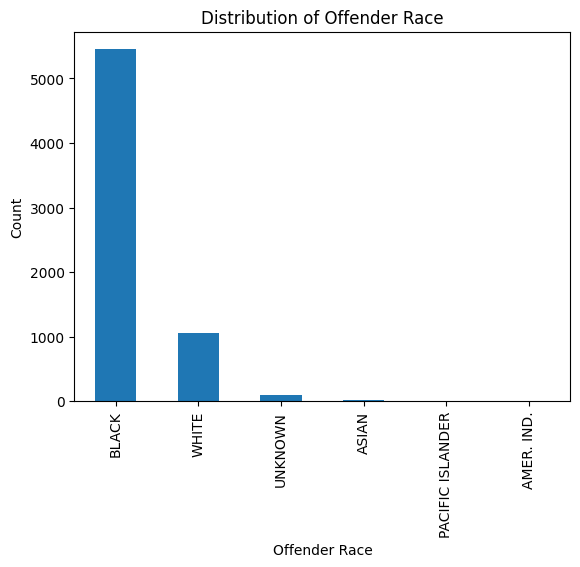

In [35]:
#visualize the the Offender_Race column
dataset['Offender_Race'].value_counts().plot(kind='bar')
plt.xlabel('Offender Race')
plt.ylabel('Count')
plt.title('Distribution of Offender Race')
plt.show()


In [28]:

# Encoding categorical data
# Encoding the Independent Variable
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

labelencoder_X = LabelEncoder()
X[:, 0] = labelencoder_X.fit_transform(X[:, 0])
ct = ColumnTransformer([("onehot", OneHotEncoder(), [0])], remainder='passthrough')
X = ct.fit_transform(X)

# Encoding the Dependent Variable
labelencoder_y = LabelEncoder()
y = labelencoder_y.fit_transform(y)

#show the encoded data
print(X)


[[0.0 1.0 0.0 ... 29.0 'Non-fatal' 'Supplemental Report']
 [0.0 1.0 0.0 ... 29.0 'Non-fatal' 'Supplemental Report']
 [0.0 1.0 0.0 ... 29.0 'Non-fatal' 'Supplemental Report']
 ...
 [0.0 1.0 0.0 ... 34.0 'Non-fatal' 'Supplemental Report']
 [0.0 1.0 0.0 ... 31.0 'Non-fatal' 'Supplemental Report']
 [0.0 1.0 0.0 ... 25.0 'Non-fatal' 'Supplemental Report']]
